<a href="https://colab.research.google.com/github/srav26/FertilityProject/blob/main/Fertility_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#filepath to folder where data is housed - specific to each group member
#juliette cd
cd="/content/drive/MyDrive/Drexel Data Science Masters/CS613 - Machine Learning/CS613 final project/"

In [ ]:
#valentina cd
cd="/content/drive/MyDrive/CS613 final project/"

In [ ]:
#sravya cd
cd= "/content/drive/MyDrive/CS613/Project/"

In [ ]:
#jinsu cd
cd = "/content/drive/MyDrive/CS613 final project/"

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
ad = pd.read_csv(cd+"FedCycleData.csv")

In [ ]:
ad.head(100)

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,...,9,,,2,7,7,1,1,0,21.254724111867
1,nfp8122,2,0,1,0,27,,15,12,13,...,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,...,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,...,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,nfp8030,1,1,1,0,29,26.75,14,15,11,...,9,,,6,4,4,1,1,0,22.4627218934911
96,nfp8030,2,1,1,0,29,,16,13,11,...,,,,,,,,,,
97,nfp8030,3,1,1,0,26,,13,13,10,...,,,,,,,,,,
98,nfp8030,4,1,1,0,25,,12,13,10,...,,,,,,,,,,


Data cleaning

In [ ]:
#clean up dataset

#1) set missing values to 'NA'
ad = ad.replace(" ", pd.NA)

#2) drop unusable variables
todrop=['Wedding','Methoddate','Timeattemptpreg','Whychart','Nextpreg','NextpregM','Medvitexplain','MedvitexplainM',
        'MensesScoreDayOne', 'MensesScoreDayTwo','MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive','MensesScoreDaySix',
        'MensesScoreDaySeven', 'MensesScoreDayEight','MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11','MensesScoreDay12',
        'MensesScoreDay13', 'MensesScoreDay14','MensesScoreDay15', 'Height', 'Weight','CycleNumber','Group','NumberofDaysofIntercourse',
        'IntercourseInFertileWindow','IntercourseDuringUnusBleed','Spousesame','AgeM', 'LivingkidsM','OccupationM','MaristatusM','ReligionM','EthnicityM',
        'SpousesameM','SchoolyearsM','MedvitsM','Reprocate','Method','Prevmethod','Gynosurgeries', 'Urosurgeries']
ad = ad.drop(todrop, axis=1)
#reasons for dropping:
    #Wedding: date variable unlegible - also not informative for this analysis because no other dates to compare to
    #Methoddate: date variable unlegible - also not informative for this analysis because no other dates to compare to
    #Timeattemptpreg: all are 0 or NA so no variation and therefore not informative
    #Whychart: not defined in codebook
    #Nextpreg: not defined in codebook
    #NextpregM: not defined in codebook
    #Medvitexplain: text response- outside scope of this analysis
    #MedvitexplainM: text response- outside scope of this analysis
    #Menses scores for each day because using total score
    #Height, Weight because using BMI
    #Cyclenumber because not meaningful variable
    #Group because this is just method of cycle tracking
    #Intercourse and Spousesame variables because we are looking at fertile window/ characteristics of mestruation, not reproductive outcomes
    #socidemographics or health data of the male partner - since we are looking at female fertility (except for male income since female income not included)
    #'Reprocate','Method','Prevmethod','Gynosurgeries', 'Urosurgeries' because all highly missing

#3) set variable type for continuous and categorical variables
#continuous
cont=('LengthofCycle', 'MeanCycleLength','EstimatedDayofOvulation', 'LengthofLutealPhase','FirstDayofHigh','TotalNumberofHighDays',
      'TotalHighPostPeak','TotalNumberofPeakDays','TotalDaysofFertility','TotalFertilityFormula', 'LengthofMenses','MeanMensesLength',
      'TotalMensesScore','MeanBleedingIntensity','Age', 'Yearsmarried', 'Numberpreg','Livingkids', 'Miscarriages', 'Abortions',
      'Boys','Girls','BMI')

for c in cont:
  ad[c] = pd.to_numeric(ad[c], errors='coerce')

#categorical
cat=('ClientID', 'CycleWithPeakorNot','ReproductiveCategory','UnusualBleeding','PhasesBleeding',
     'Maristatus', 'Religion', 'Ethnicity', 'Medvits','Breastfeeding')

for c in cat:
  ad[c] = ad[c].astype("category")

  #ordinal
  ord=('IncomeM','Schoolyears')

  for c in ord:
    ad[c] = pd.Categorical(ad[c],ordered=True)


#4) convert boys and girls to # of living children who are boys and girls
ad["Boys"] = np.where(ad["Livingkids"]> 0, ad["Boys"]/ad["Livingkids"], np.nan)
ad["Girls"] = np.where(ad["Livingkids"]> 0, ad["Girls"]/ad["Livingkids"], np.nan)

# Exploratory Data Analysis

Missingness

In [ ]:
#Examine missingness

#pd.set_option('display.max_rows', None) #run this to display all rows
ad.isnull().sum()

,0
ClientID,0
CycleWithPeakorNot,0
ReproductiveCategory,0
LengthofCycle,0
MeanCycleLength,1524
EstimatedDayofOvulation,150
LengthofLutealPhase,151
FirstDayofHigh,258
TotalNumberofHighDays,12
TotalHighPostPeak,3


Outcome variables

(array([ 37., 294., 722., 311., 159.,  73.,  24.,  11.,   2.,   1.]),
 array([ 0. ,  2.7,  5.4,  8.1, 10.8, 13.5, 16.2, 18.9, 21.6, 24.3, 27. ]),
 <BarContainer object of 10 artists>)

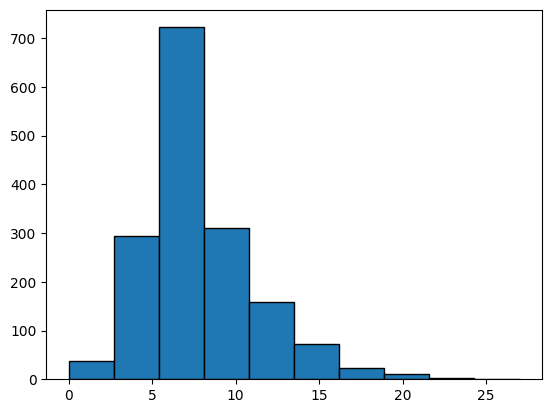

In [ ]:
#Examine continuous outcome variable (days of fertility)
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

plt.hist(ad['TotalDaysofFertility'], bins=10, edgecolor='black')


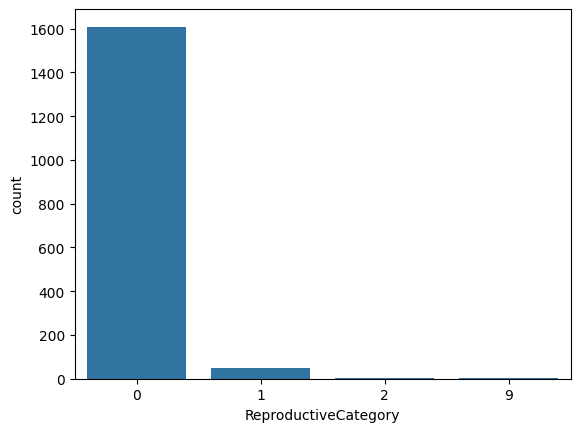

In [ ]:
#Examine categorical outcome variable (reproductive category)
sns.countplot(x='ReproductiveCategory', data=ad)
plt.show()

#highly unbalanced - must create balanced subdataset

Categorical variables

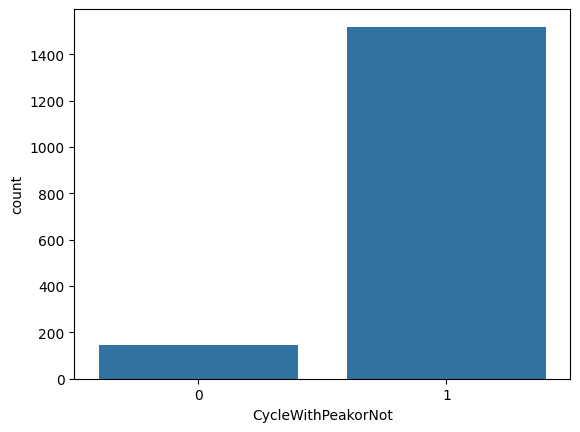

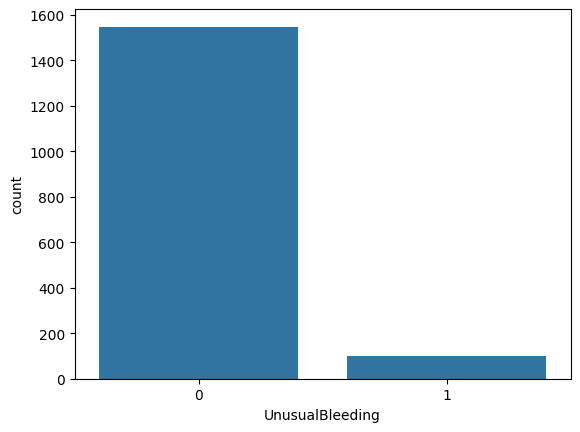

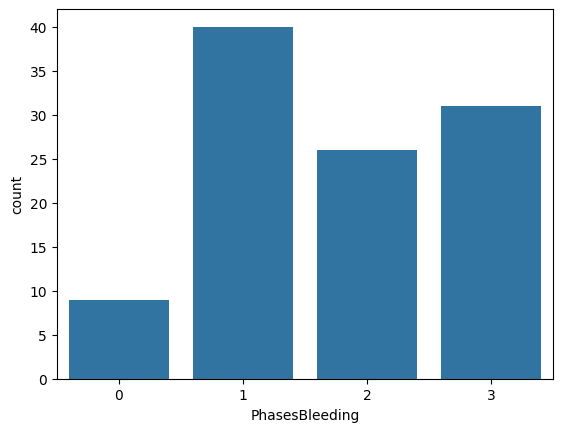

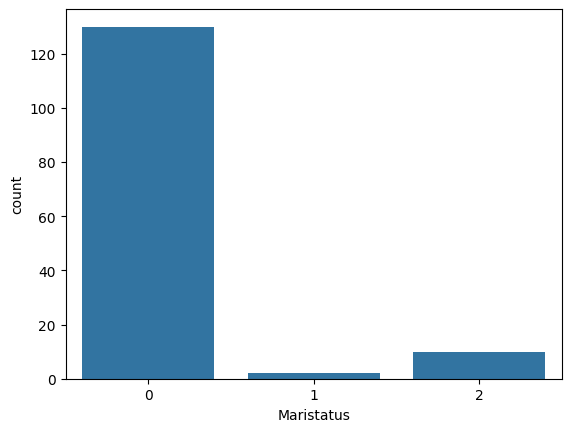

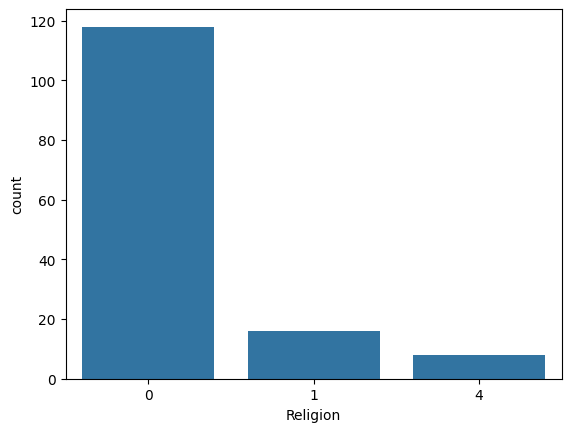

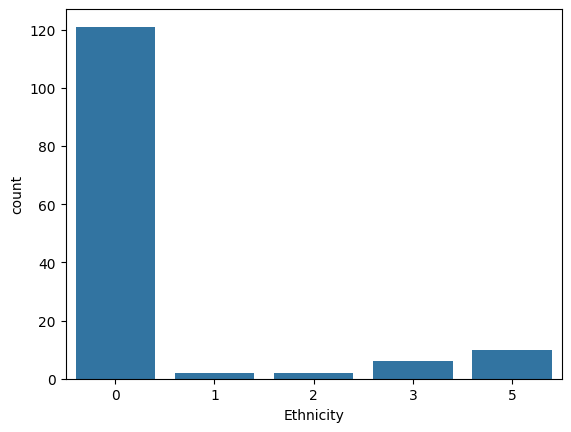

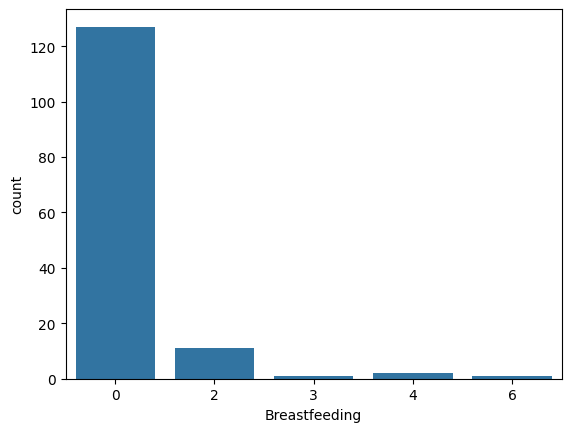

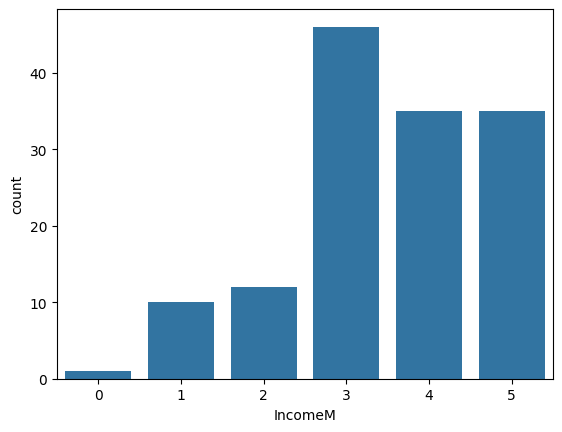

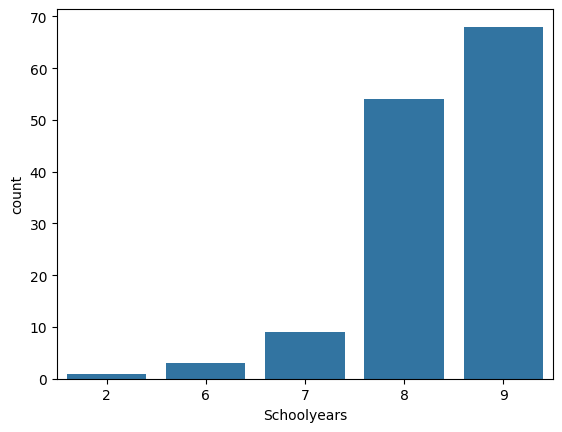

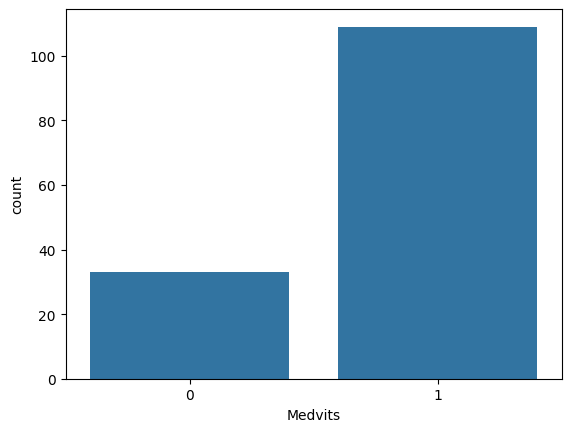

In [ ]:
## visualizing key menstrual cycle and sociodemographic categorical/ordinal exposure variables

sns.countplot(x='CycleWithPeakorNot', data=ad)
plt.show()

sns.countplot(x='UnusualBleeding', data=ad)
plt.show()

sns.countplot(x='PhasesBleeding', data=ad)
plt.show()

sns.countplot(x='Maristatus', data=ad)
plt.show()

sns.countplot(x='Religion', data=ad)
plt.show()

sns.countplot(x='Ethnicity', data=ad)
plt.show()

sns.countplot(x='Breastfeeding', data=ad)
plt.show()

sns.countplot(x='IncomeM', data=ad)
plt.show()

sns.countplot(x='Schoolyears', data=ad)
plt.show()

sns.countplot(x='Medvits', data=ad)
plt.show()

Continuous variables

In [ ]:
#explore continuous variables
ad.describe()

,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,...,MeanBleedingIntensity,Age,Yearsmarried,Numberpreg,Livingkids,Miscarriages,Abortions,Boys,Girls,BMI
count,1665.000000,141.000000,1515.000000,1514.000000,1407.000000,1653.000000,1662.000000,1649.000000,1634.000000,1663.000000,...,110.000000,142.000000,131.000000,142.000000,142.000000,139.000000,139.000000,46.000000,43.000000,131.000000
mean,29.299099,29.554255,15.963036,13.270806,11.761905,4.248034,0.133574,1.921164,7.995716,14.285628,...,9.877000,30.626761,6.656489,2.387324,2.070423,0.330935,0.035971,0.603080,0.552519,25.206891
std,3.887932,3.048391,3.548488,2.671602,3.253758,3.502879,0.613095,1.194077,3.272571,3.975657,...,2.556405,5.682634,5.133257,2.339451,1.955708,0.726202,0.222309,0.217160,0.217797,5.541611
min,18.000000,24.000000,6.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,6.000000,...,3.330000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.250000,16.826657
25%,27.000000,27.000000,14.000000,12.000000,10.000000,2.000000,0.000000,2.000000,6.000000,12.000000,...,8.032500,26.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.400000,21.086579
50%,29.000000,29.500000,15.000000,13.000000,11.000000,3.000000,0.000000,2.000000,7.000000,13.000000,...,9.940000,30.500000,6.000000,2.000000,2.000000,0.000000,0.000000,0.500000,0.500000,24.138503
75%,31.000000,31.170000,18.000000,14.000000,13.000000,5.000000,0.000000,2.000000,10.000000,16.000000,...,11.500000,35.000000,10.500000,4.000000,3.000000,0.000000,0.000000,0.666667,0.633333,27.933911
max,54.000000,40.000000,29.000000,41.000000,26.000000,22.000000,7.000000,13.000000,27.000000,37.000000,...,18.330000,43.000000,20.000000,10.000000,8.000000,4.000000,2.000000,1.000000,1.000000,49.917160


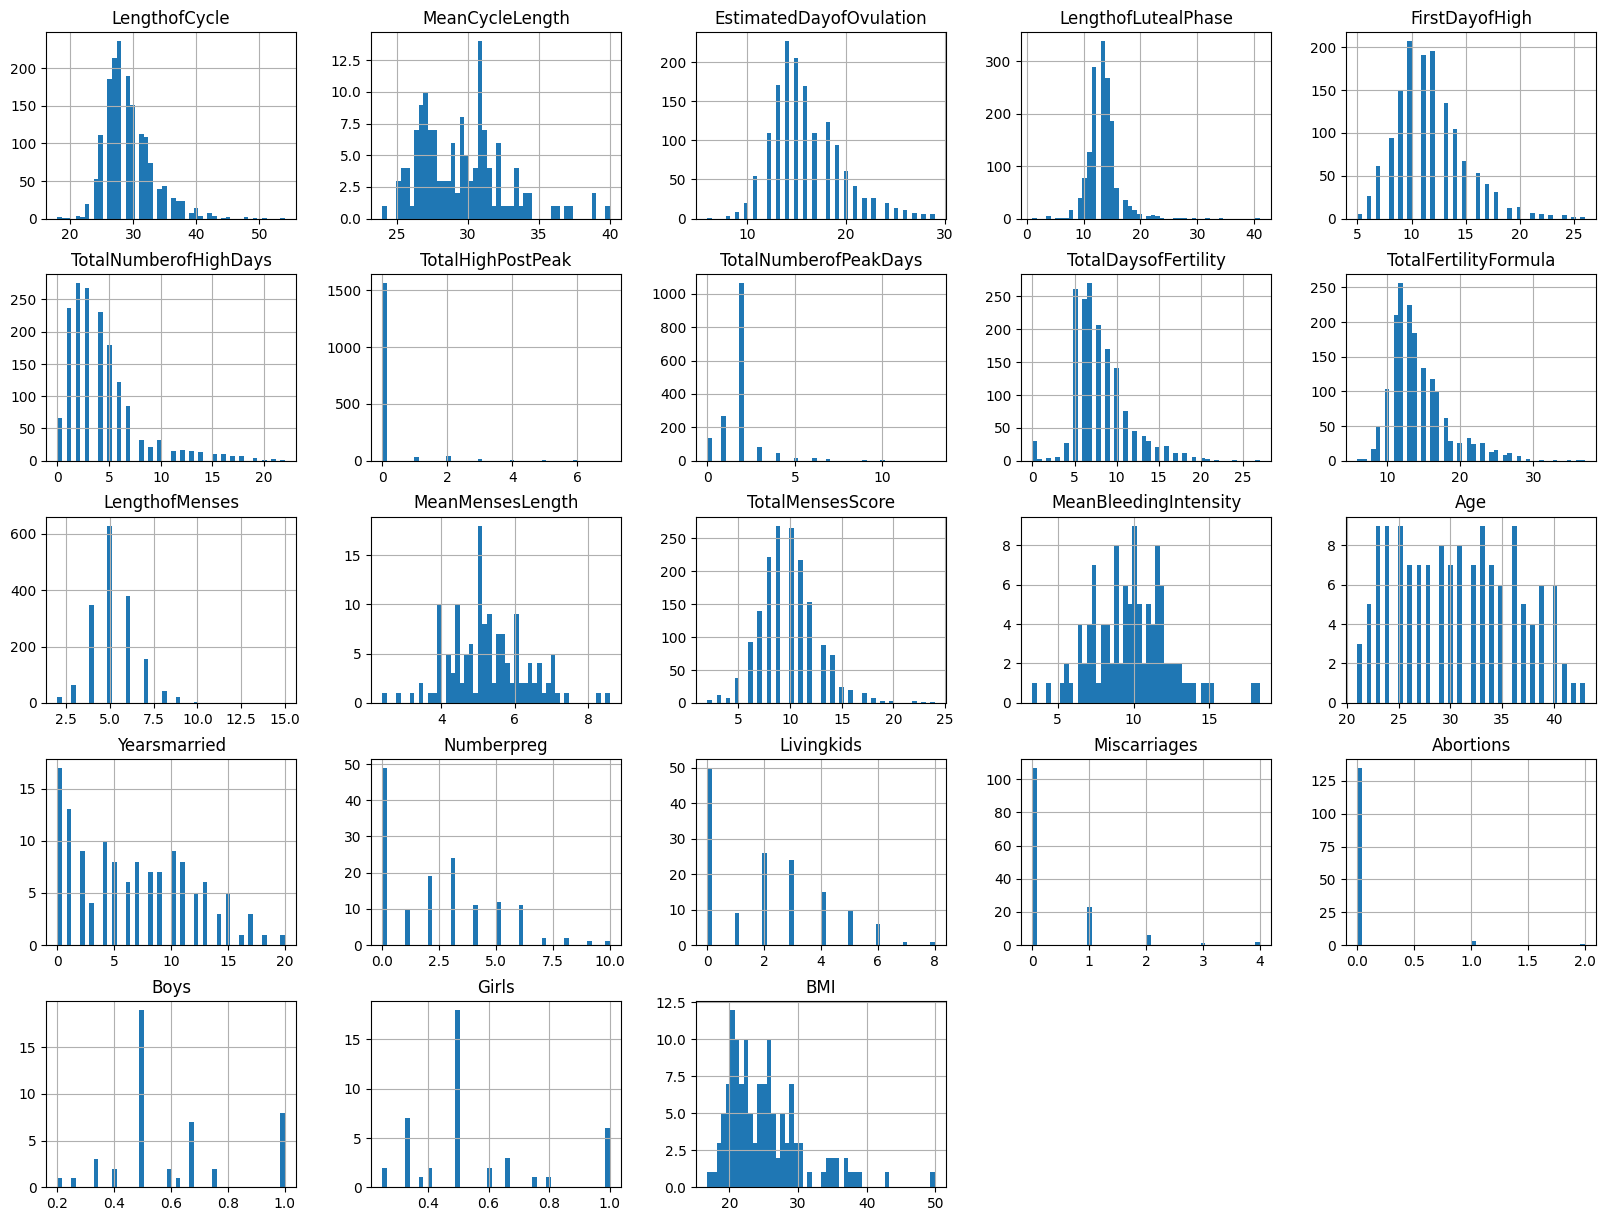

In [ ]:
## visualizing continuous exposure variables

#histograms: should log-transform any?
%matplotlib inline
import matplotlib.pyplot as plt
ad.hist(bins=50, figsize=(20,15))
plt.show()

Imputation

In [ ]:
#dealing with missing data

#1) first impute missing values by ClientID

#impute with mean for numerical
numerical_cols = ad.select_dtypes(include=np.number).columns
ad[numerical_cols] = ad[numerical_cols].fillna(ad.groupby('ClientID')[numerical_cols].transform('mean'))

#impute with mode for categorical
cat_cols = ad.select_dtypes(include="category").columns
ad[cat_cols] = ad.groupby("ClientID")[cat_cols].apply(
    lambda g: g.apply(lambda col: col.fillna(col.mode().iloc[0]) if not col.mode().empty else col)
).reset_index(level=0, drop=True)

#2) impute remaining across whole dataset

#impute with mean for numerical
numerical_cols = ad.select_dtypes(include=np.number).columns
ad[numerical_cols] = ad[numerical_cols].fillna(ad[numerical_cols].mean())

#impute with mode for categorical
cat_cols = ad.select_dtypes(include="category").columns
ad[cat_cols] = ad[cat_cols].fillna(ad[cat_cols].mode().iloc[0])

ad.head()


/tmp/ipython-input-2552173528.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad[numerical_cols] = ad[numerical_cols].fillna(ad.groupby('ClientID')[numerical_cols].transform('mean'))
/tmp/ipython-input-2552173528.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad[cat_cols] = ad.groupby("ClientID")[cat_cols].apply(


,ClientID,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,...,IncomeM,Numberpreg,Livingkids,Miscarriages,Abortions,Medvits,Boys,Girls,Breastfeeding,BMI
0,nfp8122,1,0,29,27.33,17.0,12.0,12.000000,5.0,0.0,...,5,3.0,3.0,0.0,0.0,0,0.586877,0.523583,0,21.254724
1,nfp8122,1,0,27,27.33,15.0,12.0,13.000000,2.0,0.0,...,5,3.0,3.0,0.0,0.0,0,0.586877,0.523583,0,21.254724
2,nfp8122,1,0,29,27.33,15.0,14.0,10.868421,1.0,0.0,...,5,3.0,3.0,0.0,0.0,0,0.586877,0.523583,0,21.254724
3,nfp8122,1,0,27,27.33,15.0,12.0,13.000000,2.0,0.0,...,5,3.0,3.0,0.0,0.0,0,0.586877,0.523583,0,21.254724
4,nfp8122,1,0,28,27.33,16.0,12.0,12.000000,4.0,0.0,...,5,3.0,3.0,0.0,0.0,0,0.586877,0.523583,0,21.254724


Examine relationships between variables and outcome

In [ ]:
##use T-test to understand relationship bw binary variables and days of fertility

from scipy.stats import ttest_ind

#CycleWithPeakorNot: p value = 1.84e-05 (significant)
group1 = ad[ad['CycleWithPeakorNot']==0]
group2 = ad[ad['CycleWithPeakorNot']==1]
ttest_ind(group1['TotalDaysofFertility'], group2['TotalDaysofFertility'])

#UnusualBleeding: p value = 0.0002 (significant)
group1 = ad[ad['UnusualBleeding']=='0']
group2 = ad[ad['UnusualBleeding']=='1']
ttest_ind(group1['TotalDaysofFertility'], group2['TotalDaysofFertility'])

#Medvits: p value = 0.00852 (significant)
group1 = ad[ad['Medvits']=='0']
group2 = ad[ad['Medvits']=='1']
ttest_ind(group1['TotalDaysofFertility'], group2['TotalDaysofFertility'])

#signficant association between TotalDaysofFertility and CycleWithPeakorNot, UnusualBleeding, Medvits

TtestResult(statistic=np.float64(-2.6334921946409797), pvalue=np.float64(0.008529513952576362), df=np.float64(1663.0))

In [ ]:
##use ANOVA to understand relationship bw categorical variables and days of fertility

import scipy.stats as stats

#PhasesBleeding p value = 0.3
stats.f_oneway(ad['TotalDaysofFertility'][ad['PhasesBleeding'] == '0'],
               ad['TotalDaysofFertility'][ad['PhasesBleeding'] == '1'],
               ad['TotalDaysofFertility'][ad['PhasesBleeding'] == '2'],
               ad['TotalDaysofFertility'][ad['PhasesBleeding'] == '3'])

#Maristatus p value = 1.95e-07 (significant)
stats.f_oneway(ad['TotalDaysofFertility'][ad['Maristatus'] == '0'],
               ad['TotalDaysofFertility'][ad['Maristatus'] == '1'],
               ad['TotalDaysofFertility'][ad['Maristatus'] == '2'])

#Religion p value = 0.02 (significant)
stats.f_oneway(ad['TotalDaysofFertility'][ad['Religion'] == '0'],
               ad['TotalDaysofFertility'][ad['Religion'] == '1'],
               ad['TotalDaysofFertility'][ad['Religion'] == '4'])

#Ethnicity p value = 7.62e-10 (significant)
stats.f_oneway(ad['TotalDaysofFertility'][ad['Ethnicity'] == '0'],
               ad['TotalDaysofFertility'][ad['Ethnicity'] == '1'],
               ad['TotalDaysofFertility'][ad['Ethnicity'] == '2'],
               ad['TotalDaysofFertility'][ad['Ethnicity'] == '3'],
               ad['TotalDaysofFertility'][ad['Ethnicity'] == '5'])

#Breastfeeding p value = 0.19
stats.f_oneway(ad['TotalDaysofFertility'][ad['Breastfeeding'] == '0'],
               ad['TotalDaysofFertility'][ad['Breastfeeding'] == '2'],
               ad['TotalDaysofFertility'][ad['Breastfeeding'] == '3'],
               ad['TotalDaysofFertility'][ad['Breastfeeding'] == '4'],
               ad['TotalDaysofFertility'][ad['Breastfeeding'] == '6'])

#IncomeM p value = 7.79e-06 (significant)
stats.f_oneway(ad['TotalDaysofFertility'][ad['IncomeM'] == '0'],
               ad['TotalDaysofFertility'][ad['IncomeM'] == '1'],
               ad['TotalDaysofFertility'][ad['IncomeM'] == '2'],
               ad['TotalDaysofFertility'][ad['IncomeM'] == '3'],
               ad['TotalDaysofFertility'][ad['IncomeM'] == '4'],
               ad['TotalDaysofFertility'][ad['IncomeM'] == '5'])

#Schoolyears p value = 0.016 (significant)
stats.f_oneway(ad['TotalDaysofFertility'][ad['Schoolyears'] == '2'],
               ad['TotalDaysofFertility'][ad['Schoolyears'] == '6'],
               ad['TotalDaysofFertility'][ad['Schoolyears'] == '7'],
               ad['TotalDaysofFertility'][ad['Schoolyears'] == '8'],
               ad['TotalDaysofFertility'][ad['Schoolyears'] == '9'])

#signficant association between TotalDaysofFertility and Maristatus, Religion, Ethnicity, IncomeM, Schoolyears

F_onewayResult(statistic=np.float64(3.0436259493754254), pvalue=np.float64(0.016358400870470496))

In [ ]:
##use correlation to understand relationship bw cont variables and days of fertility
pd.set_option('display.max_columns', None) #run this to display all rows
corr_matrix = ad.select_dtypes(include=['number']).corr()
corr_matrix

#Total days of fertility is highly correlated with TotalNumberofHighDays (0.78) and moderately correlated with
  #EstimatedDayofOvulation (0.34), FirstDayofHigh (-0.22), TotalNumberofPeakDays (0.23)

,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MeanMensesLength,TotalMensesScore,MeanBleedingIntensity,Age,Yearsmarried,Numberpreg,Livingkids,Miscarriages,Abortions,Boys,Girls,BMI
LengthofCycle,1.000000,0.659451,0.710780,0.361515,0.500296,0.150558,0.038001,0.069115,0.195910,0.586322,0.163329,0.127622,0.141554,0.109637,-0.173852,-0.130763,-0.135195,-0.144343,-0.066642,0.013900,0.010595,-0.006565,0.022720
MeanCycleLength,0.659451,1.000000,0.600039,0.128354,0.503404,0.099607,0.030958,0.071210,0.121008,0.449191,0.149168,0.198341,0.156705,0.165884,-0.250986,-0.179157,-0.189920,-0.191484,-0.107420,0.021017,-0.013557,0.018387,0.039365
EstimatedDayofOvulation,0.710780,0.600039,1.000000,-0.282658,0.656501,0.213714,-0.035310,0.188629,0.344214,0.756282,0.206318,0.173415,0.165345,0.137138,-0.189090,-0.111783,-0.132862,-0.152516,-0.043090,0.038541,-0.064663,-0.023945,0.040890
LengthofLutealPhase,0.361515,0.128354,-0.282658,1.000000,-0.174741,-0.021430,0.096232,-0.141110,-0.132482,-0.191964,-0.028387,-0.011116,-0.006470,-0.017568,0.024767,-0.009215,0.010129,0.029077,-0.039767,-0.019991,0.105189,0.022247,-0.008287
FirstDayofHigh,0.500296,0.503404,0.656501,-0.174741,1.000000,-0.203133,-0.113570,-0.055783,-0.220272,0.458522,0.120230,0.077507,0.084199,0.050878,-0.115713,-0.044816,-0.083790,-0.094854,-0.036846,-0.002333,-0.099150,0.006902,0.011352
TotalNumberofHighDays,0.150558,0.099607,0.213714,-0.021430,-0.203133,1.000000,0.146242,-0.232032,0.787074,0.324722,0.012597,0.023045,0.021336,-0.015146,-0.016664,-0.018194,0.008215,-0.034139,0.089554,0.093140,-0.020071,-0.015445,-0.044867
TotalHighPostPeak,0.038001,0.030958,-0.035310,0.096232,-0.113570,0.146242,1.000000,0.045602,0.124644,0.012901,0.097676,0.126087,0.083746,0.125578,-0.033083,-0.031019,0.005520,-0.010458,0.036546,-0.033889,0.038349,-0.005723,-0.078546
TotalNumberofPeakDays,0.069115,0.071210,0.188629,-0.141110,-0.055783,-0.232032,0.045602,1.000000,0.226740,0.054316,0.163673,0.170421,0.177494,0.221611,-0.056215,-0.073678,-0.018189,-0.012913,-0.014431,-0.019889,-0.072823,-0.008006,0.142546
TotalDaysofFertility,0.195910,0.121008,0.344214,-0.132482,-0.220272,0.787074,0.124644,0.226740,1.000000,0.362245,0.111465,0.115061,0.109677,0.106697,-0.063436,-0.045692,-0.027606,-0.057326,0.049457,0.071774,-0.043470,0.007053,-0.004939
TotalFertilityFormula,0.586322,0.449191,0.756282,-0.191964,0.458522,0.324722,0.012901,0.054316,0.362245,1.000000,0.157616,0.137803,0.141166,0.125112,-0.166272,-0.128660,-0.129612,-0.145770,-0.042168,0.040478,-0.030188,0.021321,0.055195


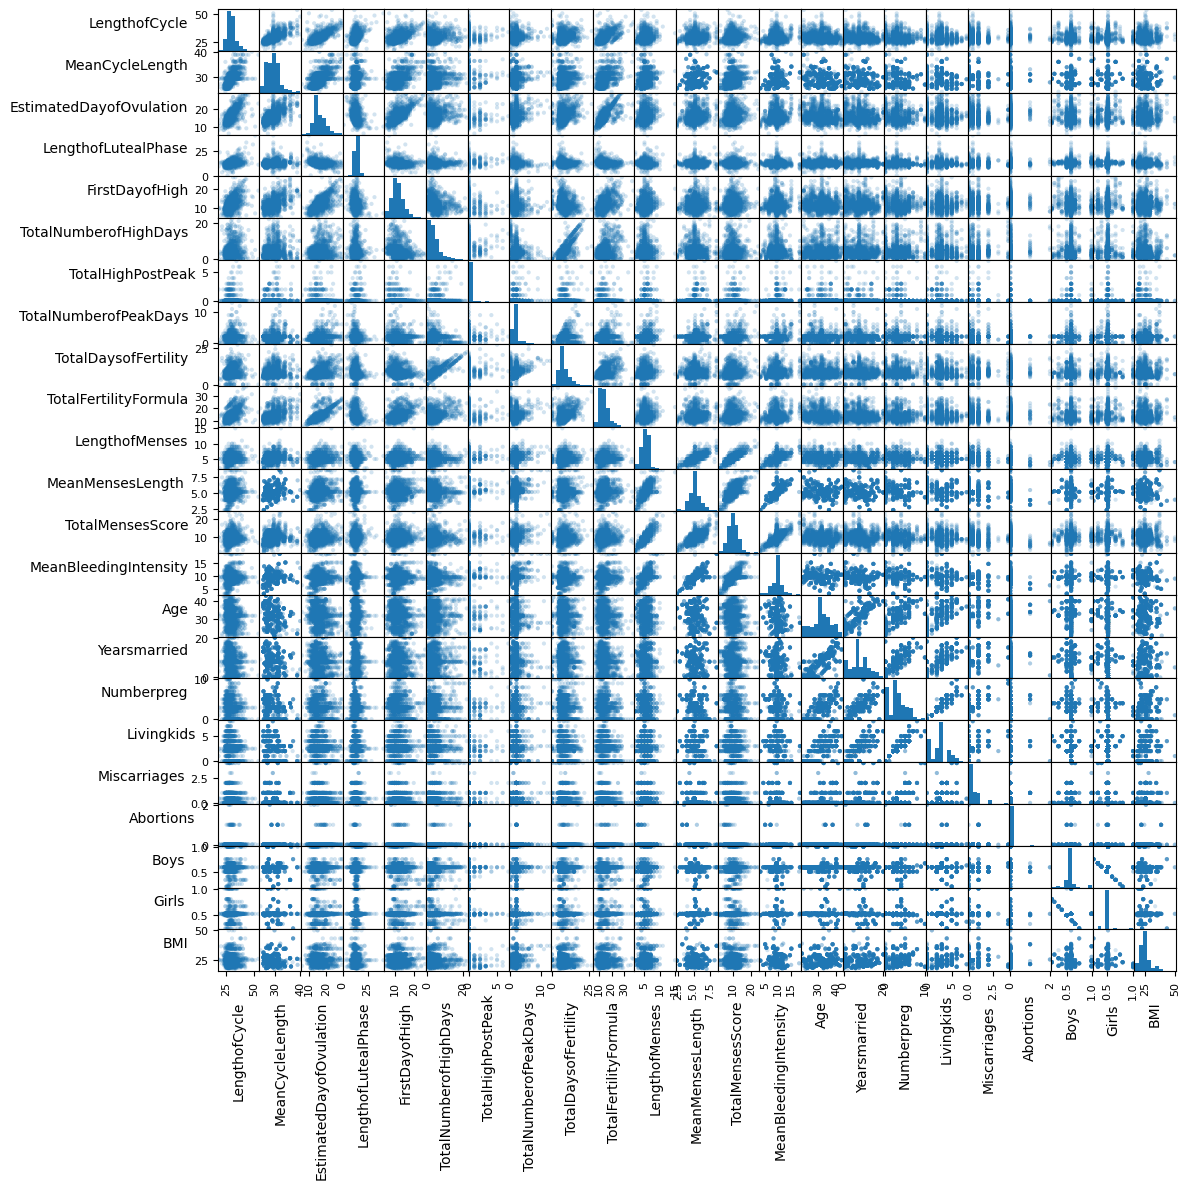

In [ ]:
#visualize correlation
from pandas.plotting import scatter_matrix

attributes = ad.select_dtypes(include=np.number).columns
#scatter_matrix(ad[attributes], figsize=(12, 12))

scat = scatter_matrix(ad[attributes], alpha=0.2, figsize=(12, 12))
for ax in scat.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

# Data Preprocessing

In [ ]:
#select features to be included in model - based on t-test, ANOVA, correlations above and apriori knowledge = 14 features

features_out=['ClientID', 'TotalDaysofFertility', 'ReproductiveCategory', 'CycleWithPeakorNot', 'UnusualBleeding', 'Medvits',
              'Maristatus', 'Religion', 'Ethnicity', 'IncomeM', 'Schoolyears', 'TotalNumberofHighDays',
              'EstimatedDayofOvulation', 'FirstDayofHigh', 'TotalNumberofPeakDays','LengthofCycle', 'Age','BMI']
ad2=ad[features_out]
ad2.head()


,ClientID,TotalDaysofFertility,ReproductiveCategory,CycleWithPeakorNot,UnusualBleeding,Medvits,Maristatus,Religion,Ethnicity,IncomeM,Schoolyears,TotalNumberofHighDays,EstimatedDayofOvulation,FirstDayofHigh,TotalNumberofPeakDays,LengthofCycle,Age,BMI
0,nfp8122,9.0,0,1,0,0,0,0,0,5,8,5.0,17.0,12.000000,2.0,29,36.0,21.254724
1,nfp8122,6.0,0,1,0,0,0,0,0,5,8,2.0,15.0,13.000000,2.0,27,36.0,21.254724
2,nfp8122,5.0,0,1,0,0,0,0,0,5,8,1.0,15.0,10.868421,2.0,29,36.0,21.254724
3,nfp8122,6.0,0,1,0,0,0,0,0,5,8,2.0,15.0,13.000000,2.0,27,36.0,21.254724
4,nfp8122,8.0,0,1,0,0,0,0,0,5,8,4.0,16.0,12.000000,2.0,28,36.0,21.254724


In [ ]:
print("Remaining nulls after imputation:")
print(ad2[features_out].isnull().mean().sort_values(ascending=False).head(50))

#none missing!

Remaining nulls after imputation:
ClientID                   0.0
TotalDaysofFertility       0.0
ReproductiveCategory       0.0
CycleWithPeakorNot         0.0
UnusualBleeding            0.0
Medvits                    0.0
Maristatus                 0.0
Religion                   0.0
Ethnicity                  0.0
IncomeM                    0.0
Schoolyears                0.0
TotalNumberofHighDays      0.0
EstimatedDayofOvulation    0.0
FirstDayofHigh             0.0
TotalNumberofPeakDays      0.0
LengthofCycle              0.0
Age                        0.0
BMI                        0.0
dtype: float64


In [ ]:
#split into training and testing data - splitting on the client level so all repeated observations follow the client

#assign clients to training or testing
clientIDs=ad2["ClientID"].unique()

train_clients, test_clients=train_test_split(clientIDs, test_size=.33, random_state=42)

#now assign observations based on which set client is in
train_set = ad2[ad2["ClientID"].isin(train_clients)]
test_set  = ad2[ad2["ClientID"].isin(test_clients)]

Preprocessing for Regression dataset (full dataset)

In [ ]:
# separate the predictors and the labels

#for regression dataset (full dataset)
x_train = train_set.drop(["TotalDaysofFertility",'ReproductiveCategory',"ClientID"], axis=1) # drop labels and ID
y_train = train_set["TotalDaysofFertility"].copy()
x_test = test_set.drop(["TotalDaysofFertility", 'ReproductiveCategory',"ClientID"], axis=1) # drop labels and ID
y_test = test_set["TotalDaysofFertility"].copy()

In [ ]:
#pre-process features
from sklearn.impute import SimpleImputer

#define categorical and continuous
cat_feat = ['CycleWithPeakorNot', 'UnusualBleeding', 'Medvits','Maristatus', 'Religion', 'Ethnicity', 'IncomeM', 'Schoolyears']
num_feat = ['TotalNumberofHighDays', 'EstimatedDayofOvulation', 'FirstDayofHigh', 'TotalNumberofPeakDays','LengthofCycle', 'Age','BMI']

#keep all possible values for caetegorical vairables
cat_categories = {col: ad2[col].astype('category').cat.categories.tolist() for col in cat_feat}

#transform cat using onehotencoder
cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(categories=[cat_categories[col] for col in cat_feat],handle_unknown='ignore',drop='first'))
])

#transform cont using z-score
num_pipeline = Pipeline([
        ('std_scaler', StandardScaler()),
    ])

#full pipeline
full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_feat),
        ("cat", cat_pipeline, cat_feat),
    ])

#fit on x_train
x_train2 = full_pipeline.fit_transform(x_train)

#transform on x_test (using x_train means/stds)
x_test2 = full_pipeline.transform(x_test)

In [ ]:
#prep for assessing feature importance for models

#extract feature names from ColumnTransformer
num_feat_out = full_pipeline.named_transformers_['num']['std_scaler'].get_feature_names_out(num_feat)

cat_feat_out = full_pipeline.named_transformers_['cat']['onehot'].get_feature_names_out(cat_feat)

all_feat = list(num_feat_out) + list(cat_feat_out)


#map transformed features onto original features (to deal with one-hot-expanded columns)
groups = {}
for feat in num_feat:
    groups[feat] = [feat]  # numeric unchanged

for feat in cat_feat:
    groups[feat] = [col for col in all_feat if col.startswith(feat)]


Preprocessing for Classification dataset (subset)

In [ ]:
# Balance the dataset
train_set["ReproductiveCategory"] = pd.to_numeric(train_set["ReproductiveCategory"], errors="coerce")
df = train_set[train_set["ReproductiveCategory"].isin([0, 1])].copy()
df_pos = df[df["ReproductiveCategory"] == 1]
df_neg = df[df["ReproductiveCategory"] == 0]

n_pos = len(df_pos)
df_neg_sampled = df_neg.sample(n=n_pos, random_state=0)

df_bal = pd.concat([df_pos, df_neg_sampled]).sample(frac=1, random_state=0).reset_index(drop=True)

print("\nBalanced class counts:")
print(df_bal["ReproductiveCategory"].value_counts())
print("Balanced shape:", df_bal[features_out].shape)


Balanced class counts:
ReproductiveCategory
0    39
1    39
Name: count, dtype: int64
Balanced shape: (78, 18)


/tmp/ipython-input-647229470.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set["ReproductiveCategory"] = pd.to_numeric(train_set["ReproductiveCategory"], errors="coerce")


In [ ]:
# separate the predictors and the labels

#for regression dataset (full dataset)
x_train_class = df_bal.drop(["TotalDaysofFertility",'ReproductiveCategory',"ClientID"], axis=1) # drop labels and ID
y_train_class = df_bal["ReproductiveCategory"].copy()

#x_test is same as that used in regression
y_test_class = test_set["ReproductiveCategory"].copy()

In [ ]:
#pre-process features

#fit on x_train
x_train_class2 = full_pipeline.fit_transform(x_train_class)

# Regression Models

###Linear Regression

In [ ]:
#Create a Linear Regression model object
linreg = LinearRegression()
linreg.fit(x_train2, y_train)
pred_lin = linreg.predict(x_test2)

#Calculate Mean Squared Error (MSE): average squared difference between actual and predicted values
mse_lr = mean_squared_error(y_test, pred_lin)
r2_lr = r2_score(y_test, pred_lin) #Calculate R-squared (R²): proportion of variance in the fertile-window length explained by the model

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr )

Linear Regression MSE: 2.8017563449017904
Linear Regression R2: 0.6951054645522539


### Random Forest

In [ ]:
#Tunning with the paramaters
param_grid = {
    'n_estimators': [100, 300, 500], #this tuning pick the best number of dataset
    'max_depth': [None, 10, 20], #decides which is best
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=0)

#Grid search will run the RF with every combination of these settings
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

#fit the tunning on training set
grid_search.fit(x_train2, y_train)
# Best model found
best_rf = grid_search.best_estimator_

print("Best Random Forest parameters:", grid_search.best_params_)

pred_rf_tuned = best_rf.predict(x_test2)

mse_tuned = mean_squared_error(y_test, pred_rf_tuned)
r2_tuned = r2_score(y_test, pred_rf_tuned)

print("Random Forest MSE:", mse_tuned)
print("Random Forest R2:", r2_tuned)



Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Random Forest MSE: 2.7150570109424295
Random Forest R2: 0.7045403153733358


### Regression Ensemble

In [ ]:
#used 0.5 to give them equal weights
pred_ensemble_reg = 0.5 * pred_lin + 0.5 * pred_rf_tuned

mse_ensemble = mean_squared_error(y_test, pred_ensemble_reg)
r2_ensemble = r2_score(y_test, pred_ensemble_reg)

print("Ensemble MSE:", mse_ensemble)
print("Ensemble R2:", r2_ensemble)

Ensemble MSE: 2.5998749148973745
Ensemble R2: 0.7170747356948809


In [ ]:
# Interpretation
rmse_lr = np.sqrt(mse_lr)
rmse_rf = np.sqrt(mse_tuned)
rmse_ensemble = np.sqrt(mse_ensemble)

print("\nINTERPRETATION OF RESULTS")
print(f"Linear Regression predicts fertile-window length with an RMSE of ~ {rmse_lr:.2f} days and explains {r2_lr*100:.1f}% of the variance.")
print(f"Random Forest achieved a similar prediction error (RMSE ~ {rmse_rf:.2f} days) and explains {r2_tuned*100:.1f}% of variance, indicating that it captures some nonlinear structure that the linear model cannot fully represent")
print(f"The ensemble model, which averages predictions from both models, improved performance further (RMSE ~ {rmse_ensemble:.2f} days) and explains {r2_ensemble*100:.1f}% of variance.This suggests that the two models capture complementary aspects of the data.")
print(f"The underlying relationship appears mostly linear, although the improvement from the ensemble indicates that some nonlinear patterns or interactions are also present.")


INTERPRETATION OF RESULTS
Linear Regression predicts fertile-window length with an RMSE of ~ 1.67 days and explains 69.5% of the variance.
Random Forest achieved a similar prediction error (RMSE ~ 1.65 days) and explains 70.5% of variance, indicating that it captures some nonlinear structure that the linear model cannot fully represent
The ensemble model, which averages predictions from both models, improved performance further (RMSE ~ 1.61 days) and explains 71.7% of variance.This suggests that the two models capture complementary aspects of the data.
The underlying relationship appears mostly linear, although the improvement from the ensemble indicates that some nonlinear patterns or interactions are also present.


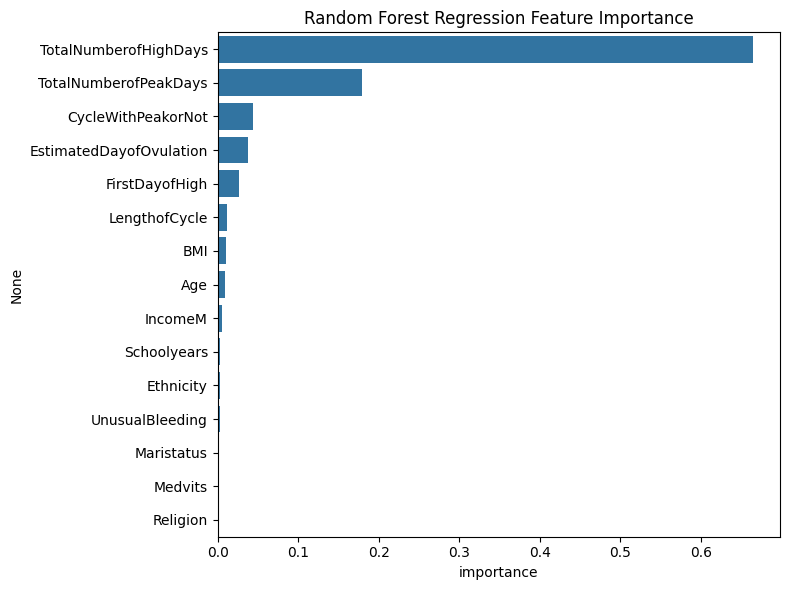

In [ ]:
#Feature importance

#aggregate importance scores
fimportance_df = pd.DataFrame({
    "feature": all_feat,
    "importance": best_rf.feature_importances_
})

agg_importance = {
    orig: fimportance_df.loc[fimportance_df["feature"].isin(cols), "importance"].sum()
    for orig, cols in groups.items()
}

agg_importance = (pd.DataFrame.from_dict(agg_importance, orient='index', columns=['importance'])).sort_values('importance', ascending=False)


plt.figure(figsize=(8,6))
sns.barplot(x=agg_importance['importance'], y=agg_importance.index)
plt.title("Random Forest Regression Feature Importance")
plt.tight_layout()
plt.show()

# Classification Models

Logistic Regression

In [ ]:
#Basic model
logreg = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)

#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['saga'],
    'l1_ratio': [0.0, 0.5, 1.0],
}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train_class2, y_train_class)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

#result
#Best parameters: {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'saga'}
#Best CV score: 0.9241666666666667

Best parameters: {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'saga'}
Best CV score: 0.9241666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [ ]:
#Update model with hyperparameters
logreg2 = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42, C=10, solver='saga', penalty='l2')


In [ ]:
# Logistic Regression Model
logreg2.fit(x_train_class2, y_train_class)
pred_log = logreg2.predict(x_test2)

In [ ]:
# Evaluate
print("=== Logistic Regression Results ===")

print("Accuracy: ", round(accuracy_score(y_test_class, pred_log), 4))
print("Precision:", round(precision_score(y_test_class, pred_log), 4))
print("Recall:   ", round(recall_score(y_test_class, pred_log), 4))
print("F1 Score: ", round(f1_score(y_test_class, pred_log), 4))

cm = confusion_matrix(y_test_class, pred_log)
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm)

=== Logistic Regression Results ===
Accuracy:  0.9105
Precision: 0.1379
Recall:    0.8889
F1 Score:  0.2388

Confusion Matrix (rows=true, cols=pred):
 [[511  50]
 [  1   8]]


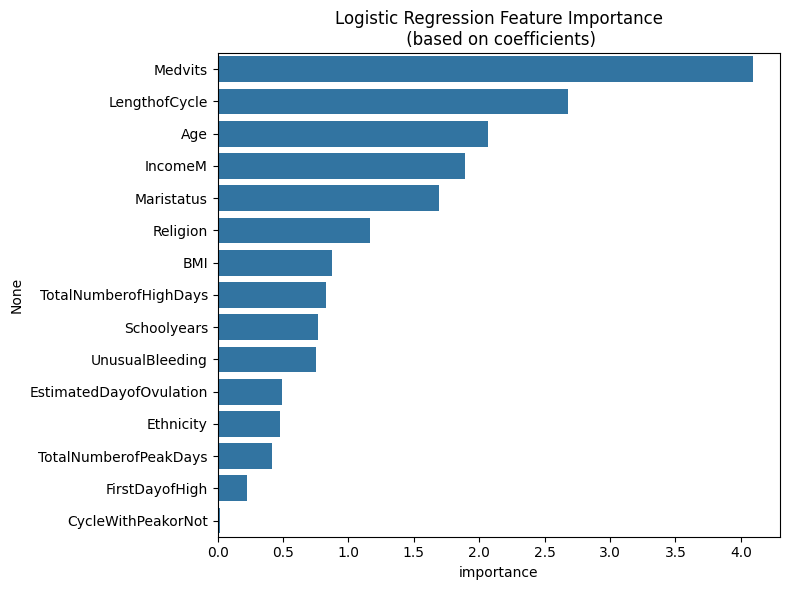

In [ ]:
#Feature importance

#get coefficients
coefs = np.abs(logreg2.coef_[0])

#aggregate importance scores (bc transformed features in model)
fimportance_df = pd.DataFrame({
    "feature": all_feat,
    "importance": coefs
})

agg_importance = {
       orig: fimportance_df.loc[fimportance_df["feature"].isin(cols), "importance"].mean() #use mean here so don't inflate importance of var with many categories
    for orig, cols in groups.items()
}

agg_importance = (pd.DataFrame.from_dict(agg_importance, orient='index', columns=['importance'])).sort_values('importance', ascending=False)


plt.figure(figsize=(8,6))
sns.barplot(x=agg_importance['importance'], y=agg_importance.index)
plt.title("Logistic Regression Feature Importance\n (based on coefficients)")
plt.tight_layout()
plt.show()

Gaussian Naive Bayes

In [ ]:
#GNB only uses numeric features so re-do preprocessing just to include z-score of cont variables
x_train_class_gnb=x_train_class.drop(cat_feat, axis=1)
x_test_class_gnb=x_test.drop(cat_feat, axis=1)

#gnb pipeline
gnb_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_feat)
    ])

#fit on x_train_class
x_train_class_gnb2 = gnb_pipeline.fit_transform(x_train_class_gnb)

#transform on x_test (using x_train_class means/stds)
x_test_class_gnb2 = gnb_pipeline.transform(x_test_class_gnb)

#use normal y_train_class and y_test_class


In [ ]:
# Train model (only uses numeric features)
gnb = GaussianNB(var_smoothing = 1e-09)
gnb.fit(x_train_class_gnb2, y_train_class)
pred_gnb= gnb.predict(x_test_class_gnb2)

In [ ]:
# Evaluation
acc = accuracy_score(y_test_class, pred_gnb)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_class, pred_gnb, average="binary", pos_label=1
)

cm = confusion_matrix(y_test_class, pred_gnb)

print("\n=== Gaussian Naive Bayes Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)


=== Gaussian Naive Bayes Results ===
Accuracy:  0.8965
Precision: 0.1094
Recall:    0.7778
F1 Score:  0.1918

Confusion Matrix (rows=true, cols=pred):
[[504  57]
 [  2   7]]


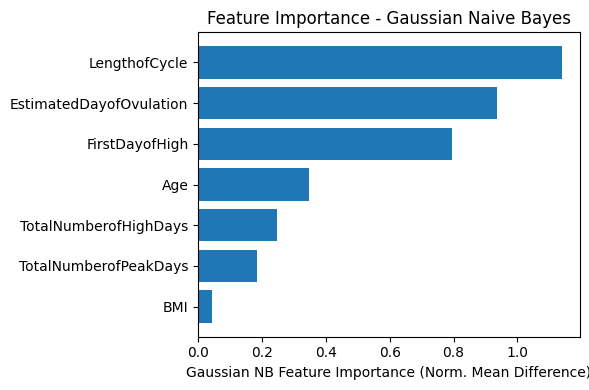

In [ ]:
#feature importance

means =gnb.theta_
variances = gnb.var_

#normalized mean diff importance
importance = np.abs(means[1] - means[0]) / np.sqrt(variances[0] + variances[1])

feat_imp = pd.DataFrame({
    "feature": num_feat,
    "importance": importance
}).sort_values(by="importance", ascending=False)


plt.figure(figsize=(6, 4))
plt.barh(feat_imp["feature"].iloc[:25][::-1],
         feat_imp["importance"].iloc[:25][::-1])
plt.xlabel("Gaussian NB Feature Importance (Norm. Mean Difference)")
plt.title("Feature Importance - Gaussian Naive Bayes")
plt.tight_layout()
plt.show()